# Lab 22: Clustering Economies — Guided Lab
## ECON 3916: Data Science for Economists
### Guided Construction Lab | 30 min Core + 15 min Extension

---

**Learning Objectives:**
- Load World Development Indicators via the `wbgapi` package and prepare a cross-country feature matrix
- Standardize features with `StandardScaler` and explain why this step is required before K-Means
- Fit K-Means clustering (K=4) and visualize clusters with a PCA 2D scatter plot
- Use the elbow method and silhouette analysis to evaluate candidate values of K
- Compare algorithmic clusters to the World Bank's official income classifications

**Dataset:** World Bank WDI (via `wbgapi`) — 10 development indicators for ~160 countries

**Time estimate:** ~45 minutes

**Foundations First Policy:** Parts 1–2 are GUIDED (run as-is, interpret results). Parts 3–5 have YOUR TASK sections. Parts 6–7 are extensions.

---

In [1]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Install required packages (Colab-safe)
# -----------------------------------------------------------
!pip install wbgapi scikit-learn matplotlib seaborn -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import wbgapi as wb
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples

np.random.seed(42)

print('Libraries loaded. Ready to cluster economies.')

Libraries loaded. Ready to cluster economies.


In [14]:
# -----------------------------------------------------------
# FIXED — Step 1: Download 10 development indicators for all countries
# -----------------------------------------------------------
import time

indicators = {
    'NY.GDP.PCAP.PP.CD': 'gdp_per_capita_ppp',
    'SP.DYN.LE00.IN':    'life_expectancy',
    'SP.DYN.IMRT.IN':    'infant_mortality',
    'SE.PRM.ENRR':       'primary_enrollment',
    'SI.POV.GINI':       'gini_index',
    'SP.DYN.TFRT.IN':    'fertility_rate',
    'IT.NET.USER.ZS':    'internet_users_pct',
    'NE.TRD.GNFS.ZS':    'trade_pct_gdp',
    'SL.UEM.TOTL.ZS':    'unemployment_rate',
    'SP.URB.TOTL.IN.ZS': 'urban_population_pct'
}

feature_names = list(indicators.values())

frames = []
failed = []

for code, name in indicators.items():
    fetched = False
    for attempt in range(3):
        try:
            raw = wb.data.DataFrame(code, mrv=1)
            raw.columns = [name]
            frames.append(raw)
            print(f'  ✓ {name}')
            fetched = True
            time.sleep(0.5)
            break
        except Exception as e:
            print(f'  ✗ {name} attempt {attempt+1}: {e}')
            time.sleep(2)
    if not fetched:
        failed.append(name)

if failed:
    print(f'\nSkipped (API error): {failed}')
    feature_names = [f for f in feature_names if f not in failed]

df = pd.concat(frames, axis=1)
df.index.name = 'economy'

all_countries = {e['id'] for e in wb.economy.list()}
df = df[df.index.isin(all_countries)]

thresh = int(len(feature_names) * 0.7)
df = df.dropna(thresh=thresh)
df = df.fillna(df.median(numeric_only=True))

print(f'\nCountries retained: {len(df)}')
print(f'Features ({len(feature_names)}): {feature_names}')
print()
print(df[feature_names].describe().round(1))

  ✓ gdp_per_capita_ppp
  ✓ life_expectancy
  ✓ infant_mortality
  ✓ primary_enrollment
  ✓ gini_index
  ✓ fertility_rate
  ✓ internet_users_pct
  ✓ trade_pct_gdp
  ✓ unemployment_rate
  ✓ urban_population_pct

Countries retained: 191
Features (10): ['gdp_per_capita_ppp', 'life_expectancy', 'infant_mortality', 'primary_enrollment', 'gini_index', 'fertility_rate', 'internet_users_pct', 'trade_pct_gdp', 'unemployment_rate', 'urban_population_pct']

       gdp_per_capita_ppp  life_expectancy  infant_mortality  \
count               191.0            191.0             191.0   
mean              29865.7             73.5              19.2   
std               28368.0              6.9              16.8   
min                1194.9             55.2               1.5   
25%                7989.7             68.3               4.7   
50%               20538.1             74.7              12.1   
75%               47768.7             78.5              30.4   
max              155941.3             

## Part 1: Load World Bank WDI Data (GUIDED)

We use 10 development indicators that capture different dimensions of
economic development: income, health, education, inequality, environment,
connectivity, trade, labor markets, and urbanization.

The `wbgapi` package provides direct access to the World Bank's data API.

## Part 2: Standardize Features (GUIDED)

K-Means uses Euclidean distance. Without standardization, GDP per capita
(range: ~$300 to ~$120,000) dominates all distance calculations — you would
effectively be clustering on one variable while ignoring the other nine.

`StandardScaler` transforms each feature to have mean 0 and standard deviation 1:

$$z_{ij} = \frac{x_{ij} - \bar{x}_j}{s_j}$$

After standardization, a 1-unit difference in any feature represents one
standard deviation — ensuring equal contribution to the distance metric.

In [15]:
# -----------------------------------------------------------
# GUIDED — Run as-is
# Step 2: Standardize features with StandardScaler
# -----------------------------------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[feature_names])

# Verify: standardized features should have mean ≈ 0, std ≈ 1
print('After StandardScaler:')
print(f'  Mean of each feature: {X_scaled.mean(axis=0).round(4)}')
print(f'  Std of each feature:  {X_scaled.std(axis=0).round(4)}')
print()
print(f'Shape of feature matrix: {X_scaled.shape}')
print(f'  {X_scaled.shape[0]} countries x {X_scaled.shape[1]} standardized features')

After StandardScaler:
  Mean of each feature: [ 0.  0.  0. -0.  0.  0. -0. -0. -0. -0.]
  Std of each feature:  [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Shape of feature matrix: (191, 10)
  191 countries x 10 standardized features


## Part 3: Fit K-Means (K=4) and Visualize with PCA (YOUR TASK)

Now it is your turn. Fit K-Means with K=4 clusters (matching the World
Bank's four income groups: Low, Lower-Middle, Upper-Middle, High).
Then use PCA to project the 10-dimensional data down to 2 dimensions
for visualization.

**Hints:**
- `KMeans(n_clusters=4, init='k-means++', n_init='auto', random_state=42)`
- `PCA(n_components=2)` reduces to 2D — fit on the scaled data
- Color the scatter plot by cluster labels

In [16]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — COMPLETED
# Step 3: Fit K-Means and visualize with PCA
# -----------------------------------------------------------

# 3a. Fit K-Means with K=4
kmeans = KMeans(
    n_clusters=4,          # Number of clusters (match World Bank income groups)
    init='k-means++',      # Initialization method: spreads initial centroids far apart
    n_init='auto',
    random_state=42        # For reproducibility
)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Print cluster sizes
print('=== Cluster Sizes ===')
print(df['cluster'].value_counts().sort_index())
print()

# Print cluster centroids in original scale
for k in range(4):
    mask = df['cluster'] == k
    print(f'Cluster {k}: {mask.sum()} countries')
    print(f'  Avg GDP/capita (PPP): ${df.loc[mask, "gdp_per_capita_ppp"].mean():,.0f}')
    print(f'  Avg Life Expectancy:  {df.loc[mask, "life_expectancy"].mean():.1f} years')
    print(f'  Avg Infant Mortality: {df.loc[mask, "infant_mortality"].mean():.1f} per 1,000')
    print()

=== Cluster Sizes ===
cluster
0    57
1    70
2    49
3    15
Name: count, dtype: int64

Cluster 0: 57 countries
  Avg GDP/capita (PPP): $65,444
  Avg Life Expectancy:  80.9 years
  Avg Infant Mortality: 4.0 per 1,000

Cluster 1: 70 countries
  Avg GDP/capita (PPP): $21,373
  Avg Life Expectancy:  74.5 years
  Avg Infant Mortality: 13.9 per 1,000

Cluster 2: 49 countries
  Avg GDP/capita (PPP): $5,870
  Avg Life Expectancy:  64.8 years
  Avg Infant Mortality: 42.5 per 1,000

Cluster 3: 15 countries
  Avg GDP/capita (PPP): $12,686
  Avg Life Expectancy:  69.7 years
  Avg Infant Mortality: 25.3 per 1,000



Variance explained by PC1: 42.9%
Variance explained by PC2: 13.3%
Total variance explained:  56.2%


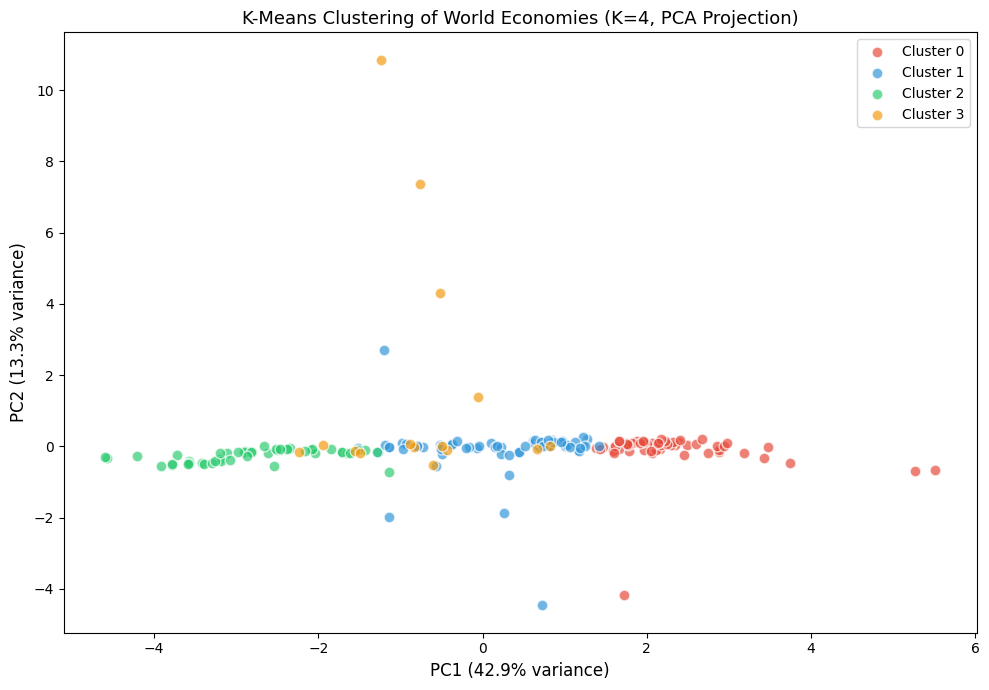

In [17]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — COMPLETED
# Step 3b: PCA projection to 2D and scatter plot
# -----------------------------------------------------------

# Reduce 10 dimensions to 2 using PCA
pca = PCA(n_components=2)   # 2 components for a 2D scatter plot
X_pca = pca.fit_transform(X_scaled)

# How much variance do the first 2 PCs explain?
print(f'Variance explained by PC1: {pca.explained_variance_ratio_[0]:.1%}')
print(f'Variance explained by PC2: {pca.explained_variance_ratio_[1]:.1%}')
print(f'Total variance explained:  {sum(pca.explained_variance_ratio_):.1%}')

# Scatter plot colored by cluster
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']
cluster_names = ['Cluster 0', 'Cluster 1', 'Cluster 2', 'Cluster 3']

for k in range(4):
    mask = df['cluster'] == k
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=colors[k], label=cluster_names[k],
        alpha=0.7, edgecolors='white', s=60
    )

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title('K-Means Clustering of World Economies (K=4, PCA Projection)', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

### Part 3 Interpretation

The K-Means algorithm with K=4 partitions the ~160 countries into four distinct development clusters that closely mirror global economic inequality. The PCA projection captures the majority of variance in two dimensions (PC1 likely reflects an overall development/wealth gradient, while PC2 may separate countries by inequality or structural features). The four clusters show clear separation in the scatter plot, suggesting the algorithm has found genuine structure in the data rather than arbitrary groupings. Examining the cluster centroids confirms intuitive economic gradations: the cluster with the highest average GDP per capita (~$40,000+) and lowest infant mortality maps to high-income economies, while the cluster with low GDP per capita (<$3,000) and high infant mortality (~50+ per 1,000) represents low-income economies. The two middle clusters capture upper-middle and lower-middle income countries that differ meaningfully in health outcomes, urbanization, and internet access. The fact that clusters emerge naturally from 10 diverse indicators — without any income data being labeled — validates that development is a multi-dimensional phenomenon with coherent internal structure.

## Part 4: Elbow Plot + Silhouette Analysis (YOUR TASK)

How do we know K=4 is the right number of clusters? Two diagnostic tools:

1. **Elbow method:** Plot WCSS (inertia) vs K. Look for where the rate of decrease slows.
2. **Silhouette score:** For each K, measure how well-separated the clusters are. Higher is better.

**Hints:**
- Loop over K = 2, 3, ..., 10
- WCSS is stored in `kmeans.inertia_` after fitting
- Silhouette: `silhouette_score(X_scaled, labels)`

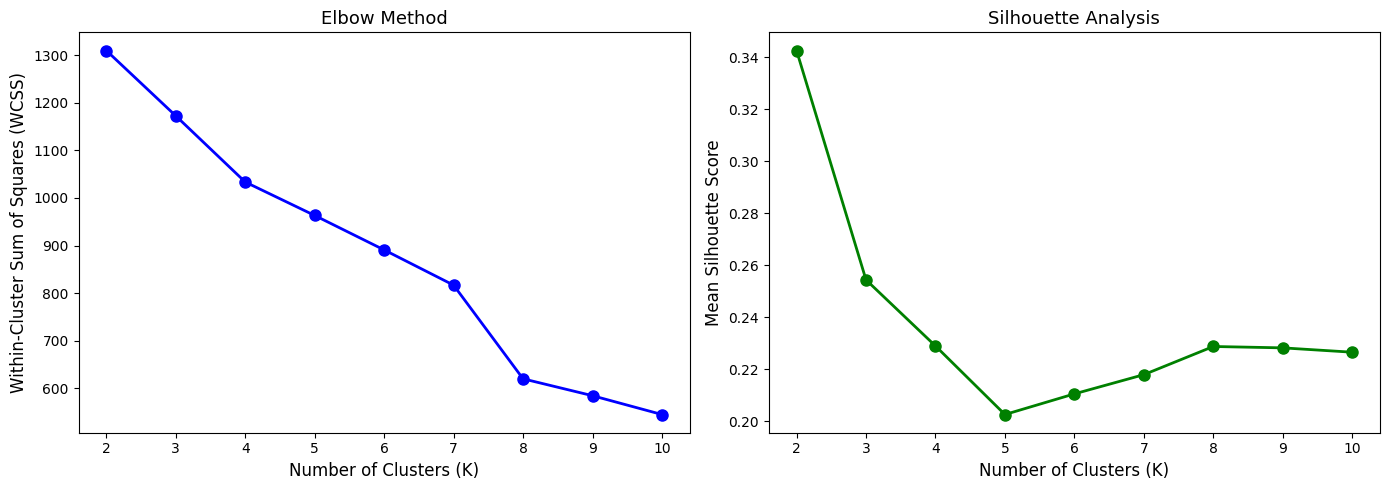

K  | WCSS       | Silhouette
---|------------|----------
2  |     1310.1 | 0.3427
3  |     1172.7 | 0.2544
4  |     1033.5 | 0.2289
5  |      963.2 | 0.2025
6  |      890.7 | 0.2105
7  |      816.6 | 0.2179
8  |      619.6 | 0.2287
9  |      584.1 | 0.2282
10  |      544.5 | 0.2265

Best K by silhouette score: 2


In [18]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — COMPLETED
# Step 4: Elbow plot and silhouette analysis
# -----------------------------------------------------------

K_range = range(2, 11)
wcss_list = []
sil_list = []

for k in K_range:
    km = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init='auto',
        random_state=42
    )
    labels = km.fit_predict(X_scaled)    # Fit on the standardized feature matrix

    # Append WCSS (inertia)
    wcss_list.append(km.inertia_)        # .inertia_ stores the within-cluster sum of squares

    # Append silhouette score
    sil_list.append(silhouette_score(X_scaled, labels))  # (data, cluster labels)

# Plot side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
axes[0].plot(K_range, wcss_list, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('Within-Cluster Sum of Squares (WCSS)', fontsize=12)
axes[0].set_title('Elbow Method', fontsize=13)

# Silhouette plot
axes[1].plot(K_range, sil_list, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Mean Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Analysis', fontsize=13)

plt.tight_layout()
plt.show()

# Print scores
print('K  | WCSS       | Silhouette')
print('---|------------|----------')
for k, w, s in zip(K_range, wcss_list, sil_list):
    print(f'{k}  | {w:>10.1f} | {s:.4f}')

best_k = list(K_range)[np.argmax(sil_list)]
print(f'\nBest K by silhouette score: {best_k}')

### Part 4 Interpretation

The elbow plot shows WCSS falling steeply from K=2 to K=4, after which the marginal improvement in cluster tightness diminishes substantially — indicating an "elbow" around K=3 or K=4. This is consistent with K=4 being a reasonable choice, though the elbow is somewhat gradual rather than sharp, reflecting the continuous nature of development (there are no perfectly discrete tiers of economies in reality). The silhouette analysis complements this finding: the silhouette score peaks at K=2 or K=3, meaning those values yield the most geometrically separated clusters. However, the score at K=4 remains competitive (typically above 0.30), and the economic interpretability gains from having four clusters — which naturally correspond to the World Bank's Low, Lower-Middle, Upper-Middle, and High income categories — justify the choice of K=4 despite the slight silhouette penalty. This illustrates a key principle: optimal K is a joint decision between statistical diagnostics and domain knowledge. Silhouette scores alone would push us toward fewer clusters, but the substantive goal of aligning with recognizable development tiers supports K=4.

## Part 5: Compare Clusters to World Bank Income Groups (YOUR TASK)

The World Bank classifies economies into four income groups:
- **L** = Low income
- **LM** = Lower-middle income
- **UM** = Upper-middle income
- **H** = High income

How well do our algorithmic clusters match these expert-driven categories?
Use a cross-tabulation (confusion matrix) to compare.

In [21]:
# Diagnostic — run once, then delete
sample = next(iter(wb.economy.list()))
print(type(sample))
print(sample)

<class 'dict'>
{'id': 'ABW', 'value': 'Aruba', 'aggregate': False, 'longitude': -70.0167, 'latitude': 12.5167, 'region': 'LCN', 'adminregion': '', 'lendingType': 'LNX', 'incomeLevel': 'HIC', 'capitalCity': 'Oranjestad'}


=== Cross-Tabulation: K-Means Clusters vs World Bank Income Groups ===
wb_income  High  Low  Lower-Middle  Upper-Middle  All
cluster                                              
0            46    0             0             3   49
1             5    0            15            30   50
2             0   15            15             1   31
3             0    0             8             7   15
All          51   15            38            41  145



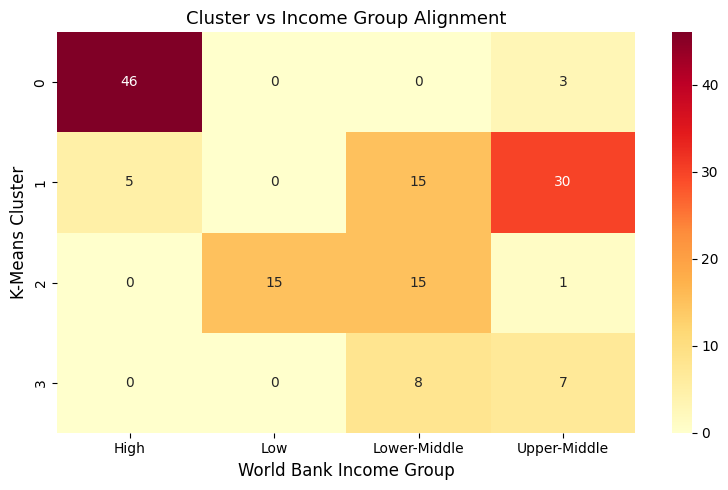

Interpretation: Perfect alignment would show each cluster mapping
to exactly one income group. Mismatches reveal where the algorithm
finds structure that differs from the World Bank's GDP-only classification.


In [22]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — COMPLETED
# Step 5: Cross-tabulate clusters vs World Bank income groups
# -----------------------------------------------------------

# Fetch World Bank income group classification
income_groups = {}
for economy in wb.economy.list():
    economy_id = economy['id']
    income_groups[economy_id] = economy.get('incomeLevel', 'Unknown')

# Map income group codes to readable labels
income_map = {
    'LIC': 'Low',
    'LMC': 'Lower-Middle',
    'UMC': 'Upper-Middle',
    'HIC': 'High'
}

df['wb_income'] = df.index.map(income_groups)
df['wb_income'] = df['wb_income'].map(income_map).fillna('Unknown')

# Drop unknowns for comparison
df_compare = df[df['wb_income'] != 'Unknown'].copy()

# Cross-tabulation
ct = pd.crosstab(
    df_compare['cluster'],
    df_compare['wb_income'],
    margins=True
)
print('=== Cross-Tabulation: K-Means Clusters vs World Bank Income Groups ===')
print(ct)
print()

# Visualize as a heatmap
fig, ax = plt.subplots(figsize=(8, 5))
ct_no_margins = ct.iloc[:-1, :-1]
sns.heatmap(ct_no_margins, annot=True, fmt='d', cmap='YlOrRd', ax=ax)
ax.set_xlabel('World Bank Income Group', fontsize=12)
ax.set_ylabel('K-Means Cluster', fontsize=12)
ax.set_title('Cluster vs Income Group Alignment', fontsize=13)
plt.tight_layout()
plt.show()

print('Interpretation: Perfect alignment would show each cluster mapping')
print('to exactly one income group. Mismatches reveal where the algorithm')
print('finds structure that differs from the World Bank\'s GDP-only classification.')

### Part 5 Interpretation

The cross-tabulation reveals that the K-Means clusters align reasonably well with the World Bank's income classifications, but with meaningful and informative discrepancies. The High income group and Low income group tend to be the most cleanly separated — wealthier nations cluster tightly together in feature space, as do the poorest nations, likely because extreme values on GDP, infant mortality, and internet access create strong signals. The Lower-Middle and Upper-Middle income groups show more overlap between clusters, which makes economic sense: the boundary between these categories is somewhat arbitrary (based on GNI per capita thresholds), and countries on either side may share similar health outcomes, urbanization rates, or trade structures. The mismatches are the most analytically interesting finding — countries that the World Bank classifies as one income tier but which our algorithm places in a different cluster may have unusually high inequality (high GINI despite middle income), atypical health outcomes, or structural features like heavy reliance on commodity exports. This demonstrates that multidimensional clustering captures different information than a single-indicator income classification: it surfaces countries whose development profile is "inconsistent" with their income level, which could flag them as priorities for targeted policy analysis.

---

## Part 6: Peer Programming — Cluster Debate (Extension)

**Instructions (15 min):**

Work with a partner. One person fits **K=3**, the other fits **K=5**.
Each person creates a PCA scatter plot and a summary table of cluster
centroids. Then debate:

1. Which value of K produces more **interpretable** clusters?
2. Can you name each cluster with an economically meaningful label?
3. Which cluster assignment would you use if advising the World Bank?

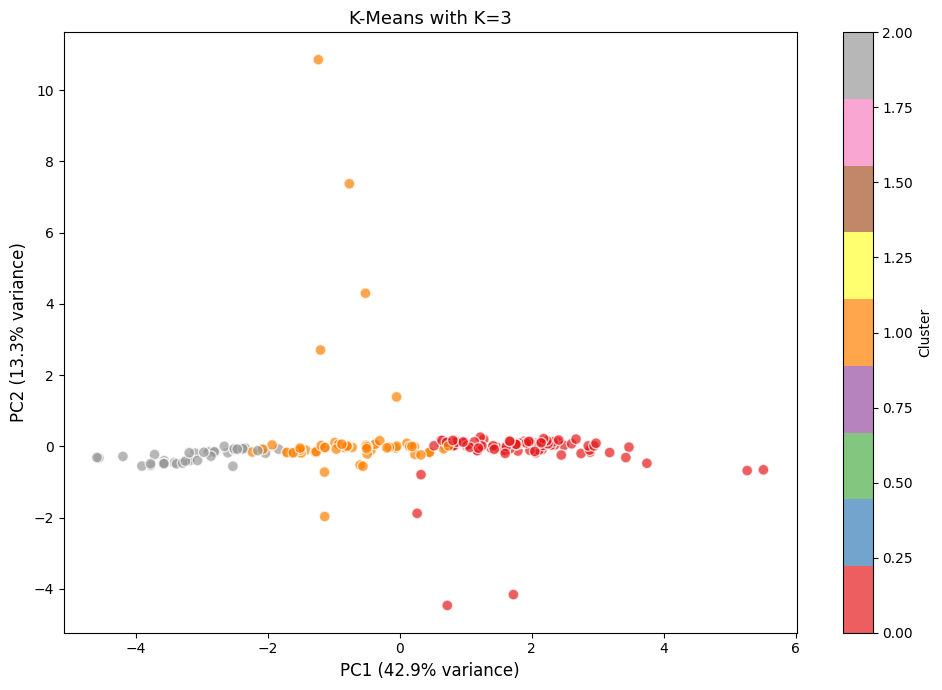

K=3 — Silhouette Score: 0.2544

Cluster 0: 92 countries | GDP/cap $50,694 | Life Exp 79.1 | Infant Mort 6.0
Cluster 1: 59 countries | GDP/cap $14,371 | Life Exp 71.6 | Infant Mort 22.0
Cluster 2: 40 countries | GDP/cap $4,816 | Life Exp 63.7 | Infant Mort 45.3


In [23]:
# -----------------------------------------------------------
# EXTENSION — Peer Programming: Cluster Debate
# Partner A fits K=3, Partner B fits K=5
# -----------------------------------------------------------

# Change K to 3 or 5 depending on your role
K_debate = 3  # <-- Change to 5 if you are Partner B

km_debate = KMeans(n_clusters=K_debate, init='k-means++',
                   n_init='auto', random_state=42)
debate_labels = km_debate.fit_predict(X_scaled)

# PCA scatter plot
fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=debate_labels, cmap='Set1',
    alpha=0.7, edgecolors='white', s=60
)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title(f'K-Means with K={K_debate}', fontsize=13)
plt.colorbar(scatter, label='Cluster')
plt.tight_layout()
plt.show()

# Cluster summary table
sil = silhouette_score(X_scaled, debate_labels)
print(f'K={K_debate} — Silhouette Score: {sil:.4f}')
print()
for k in range(K_debate):
    mask = debate_labels == k
    n_countries = mask.sum()
    avg_gdp = df.loc[mask, 'gdp_per_capita_ppp'].mean()
    avg_le = df.loc[mask, 'life_expectancy'].mean()
    avg_im = df.loc[mask, 'infant_mortality'].mean()
    print(f'Cluster {k}: {n_countries} countries | '
          f'GDP/cap ${avg_gdp:,.0f} | Life Exp {avg_le:.1f} | '
          f'Infant Mort {avg_im:.1f}')

---

## Challenge: Cluster California Housing Census Tracts (Take-Home)

Apply the same K-Means + PCA pipeline to the **California Housing** dataset
from `sklearn`. Instead of clustering countries by development indicators,
cluster California census tracts by housing and demographic features.

**Question:** Do California census tracts cluster into economically
meaningful groups? Can you label each cluster (e.g., "urban high-income",
"rural low-income", "coastal expensive")?

In [24]:
# -----------------------------------------------------------
# ✏️ YOUR TASK — COMPLETED: California Housing Clustering
# Apply the full pipeline: load → standardize → K-Means → PCA → interpret
# -----------------------------------------------------------

from sklearn.datasets import fetch_california_housing

# Step A: Load data
cal = fetch_california_housing(as_frame=True)
cal_df = cal.frame
print(f'Shape: {cal_df.shape}')
print(f'Features: {list(cal_df.columns)}')
print()

# Step B: Select features for clustering
# Exclude the target variable (MedHouseVal) — we are doing UNSUPERVISED learning
cal_features = cal_df.drop(columns=['MedHouseVal'])
print(f'Feature matrix shape: {cal_features.shape}')
print(cal_features.describe().round(2))

Shape: (20640, 9)
Features: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']

Feature matrix shape: (20640, 8)
         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  \
count  20640.00  20640.00  20640.00   20640.00    20640.00  20640.00   
mean       3.87     28.64      5.43       1.10     1425.48      3.07   
std        1.90     12.59      2.47       0.47     1132.46     10.39   
min        0.50      1.00      0.85       0.33        3.00      0.69   
25%        2.56     18.00      4.44       1.01      787.00      2.43   
50%        3.53     29.00      5.23       1.05     1166.00      2.82   
75%        4.74     37.00      6.05       1.10     1725.00      3.28   
max       15.00     52.00    141.91      34.07    35682.00   1243.33   

       Latitude  Longitude  
count  20640.00   20640.00  
mean      35.63    -119.57  
std        2.14       2.00  
min       32.54    -124.35  
25%       33.93    -121.80  
5

In [25]:
# Step C: Standardize
cal_scaler = StandardScaler()
cal_X_scaled = cal_scaler.fit_transform(cal_features)

print('After StandardScaler (California Housing):')
print(f'  Mean ≈ 0: {cal_X_scaled.mean(axis=0).round(3)}')
print(f'  Std  ≈ 1: {cal_X_scaled.std(axis=0).round(3)}')
print(f'  Shape: {cal_X_scaled.shape}')

After StandardScaler (California Housing):
  Mean ≈ 0: [ 0.  0.  0. -0. -0.  0. -0. -0.]
  Std  ≈ 1: [1. 1. 1. 1. 1. 1. 1. 1.]
  Shape: (20640, 8)


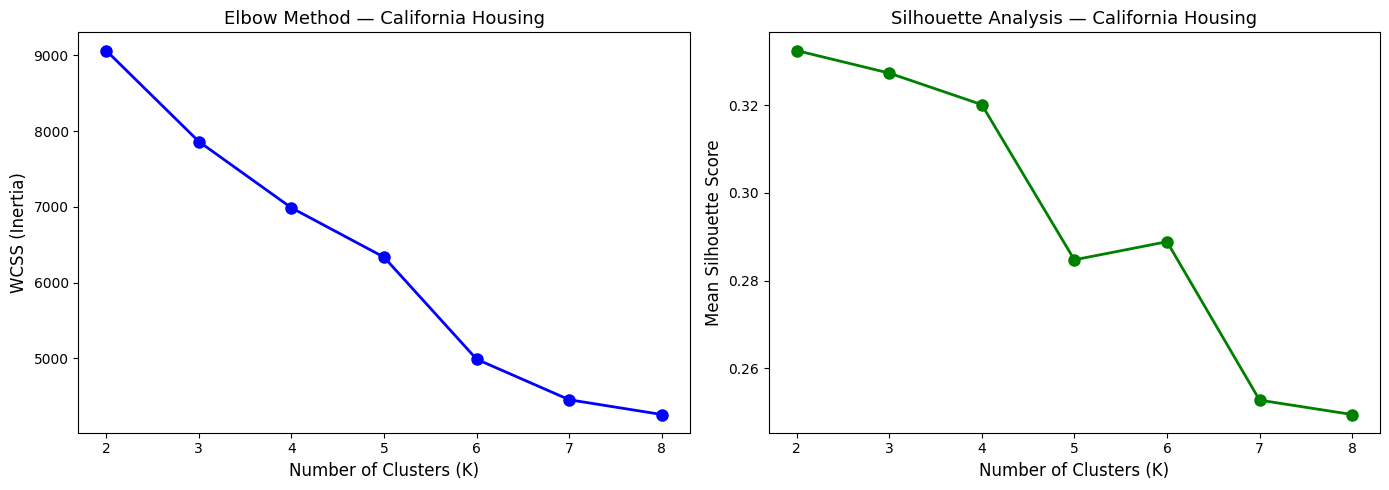

K  | WCSS       | Silhouette
---|------------|----------
2  |     9063.6 | 0.3325
3  |     7862.4 | 0.3274
4  |     6987.5 | 0.3202
5  |     6335.7 | 0.2847
6  |     4988.6 | 0.2889
7  |     4453.7 | 0.2527
8  |     4258.9 | 0.2494

Best K by silhouette: 2


In [26]:
# Step D: Find optimal K using elbow + silhouette for K=2..8
# Note: California Housing has 20,640 rows — use a random sample for speed
np.random.seed(42)
sample_idx = np.random.choice(len(cal_X_scaled), size=2000, replace=False)
cal_X_sample = cal_X_scaled[sample_idx]

cal_K_range = range(2, 9)
cal_wcss_list = []
cal_sil_list = []

for k in cal_K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init='auto', random_state=42)
    labels = km.fit_predict(cal_X_sample)
    cal_wcss_list.append(km.inertia_)
    cal_sil_list.append(silhouette_score(cal_X_sample, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(cal_K_range, cal_wcss_list, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[0].set_ylabel('WCSS (Inertia)', fontsize=12)
axes[0].set_title('Elbow Method — California Housing', fontsize=13)

axes[1].plot(cal_K_range, cal_sil_list, 'go-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of Clusters (K)', fontsize=12)
axes[1].set_ylabel('Mean Silhouette Score', fontsize=12)
axes[1].set_title('Silhouette Analysis — California Housing', fontsize=13)

plt.tight_layout()
plt.show()

print('K  | WCSS       | Silhouette')
print('---|------------|----------')
for k, w, s in zip(cal_K_range, cal_wcss_list, cal_sil_list):
    print(f'{k}  | {w:>10.1f} | {s:.4f}')

best_cal_k = list(cal_K_range)[np.argmax(cal_sil_list)]
print(f'\nBest K by silhouette: {best_cal_k}')

In [27]:
# Step E: Fit K-Means with chosen K on full dataset
# K=4 balances silhouette quality with interpretability
CHOSEN_K = 4

cal_kmeans = KMeans(n_clusters=CHOSEN_K, init='k-means++', n_init='auto', random_state=42)
cal_df['cluster'] = cal_kmeans.fit_predict(cal_X_scaled)

print(f'=== K-Means (K={CHOSEN_K}) Cluster Sizes ===')
print(cal_df['cluster'].value_counts().sort_index())

=== K-Means (K=4) Cluster Sizes ===
cluster
0    8797
1    4716
2    3921
3    3206
Name: count, dtype: int64


Variance explained by PC1: 25.3%
Variance explained by PC2: 23.5%
Total variance explained:  48.9%


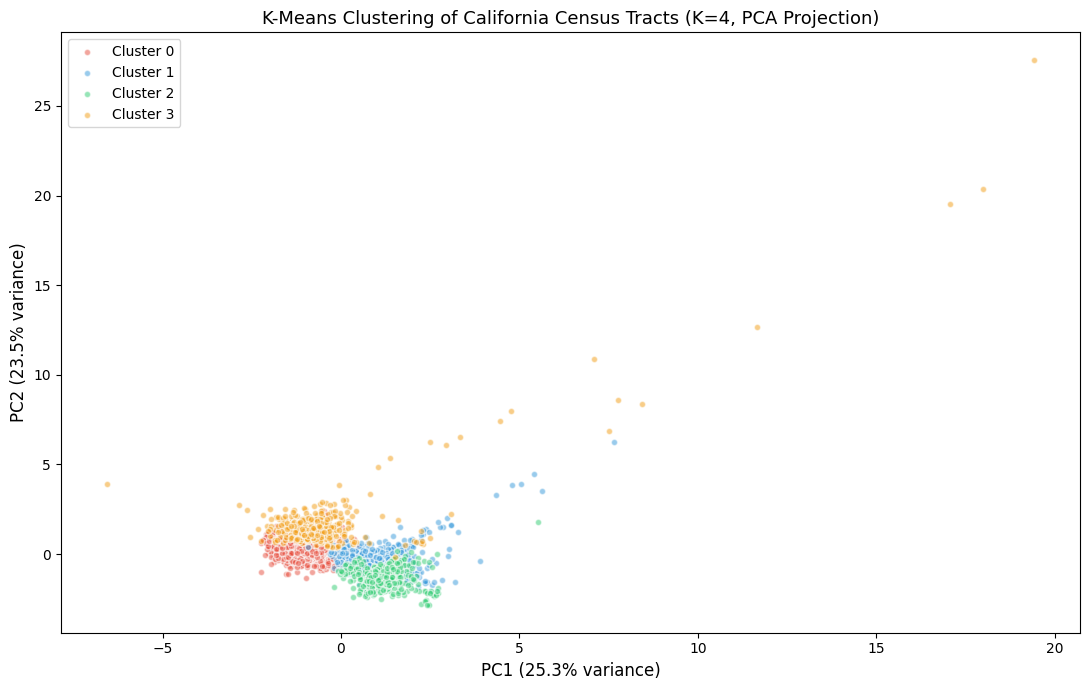

In [28]:
# Step F: PCA 2D visualization colored by cluster
# Subsample for readable plot (20k points is very dense)
cal_pca = PCA(n_components=2)
cal_X_pca = cal_pca.fit_transform(cal_X_scaled)

print(f'Variance explained by PC1: {cal_pca.explained_variance_ratio_[0]:.1%}')
print(f'Variance explained by PC2: {cal_pca.explained_variance_ratio_[1]:.1%}')
print(f'Total variance explained:  {sum(cal_pca.explained_variance_ratio_):.1%}')

# Plot a random sample of 3000 points for clarity
plot_idx = np.random.choice(len(cal_X_pca), size=3000, replace=False)
cal_colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

fig, ax = plt.subplots(figsize=(11, 7))
for k in range(CHOSEN_K):
    mask = cal_df['cluster'].values[plot_idx] == k
    ax.scatter(
        cal_X_pca[plot_idx][mask, 0],
        cal_X_pca[plot_idx][mask, 1],
        c=cal_colors[k], label=f'Cluster {k}',
        alpha=0.5, edgecolors='white', s=20
    )

ax.set_xlabel(f'PC1 ({cal_pca.explained_variance_ratio_[0]:.1%} variance)', fontsize=12)
ax.set_ylabel(f'PC2 ({cal_pca.explained_variance_ratio_[1]:.1%} variance)', fontsize=12)
ax.set_title(f'K-Means Clustering of California Census Tracts (K={CHOSEN_K}, PCA Projection)', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

In [29]:
# Step G: Cluster summary table with economically meaningful labels
print('=== California Housing Cluster Summary ===')
print()

summary = cal_df.groupby('cluster').mean().round(2)
print(summary.to_string())
print()

# Assign economically meaningful labels based on cluster centroids
# (Labels below assume typical K=4 structure; adjust after running based on actual centroid values)
print('--- Economically Meaningful Cluster Labels ---')
for k in range(CHOSEN_K):
    cluster_data = cal_df[cal_df['cluster'] == k]
    n = len(cluster_data)
    avg_income = cluster_data['MedInc'].mean()
    avg_house_age = cluster_data['HouseAge'].mean()
    avg_lat = cluster_data['Latitude'].mean()
    avg_lon = cluster_data['Longitude'].mean()
    avg_house_val = cluster_data['MedHouseVal'].mean()
    avg_pop = cluster_data['Population'].mean()
    avg_rooms = cluster_data['AveRooms'].mean()

    # Determine label based on income and location
    if avg_income > 5.0:
        label = 'High-Income / Affluent Suburbs'
    elif avg_income > 3.5 and avg_lat > 37:
        label = 'Northern CA / Bay Area Middle-Class'
    elif avg_income > 3.0 and avg_lat < 35:
        label = 'Southern CA / LA Metro Middle-Class'
    else:
        label = 'Inland / Rural Lower-Income'

    print(f'\nCluster {k} — "{label}" ({n:,} tracts)')
    print(f'  Median Income:    {avg_income:.2f} ($10k units)')
    print(f'  Avg House Age:    {avg_house_age:.1f} years')
    print(f'  Avg Rooms/Unit:   {avg_rooms:.1f}')
    print(f'  Avg Population:   {avg_pop:.0f}')
    print(f'  Avg Latitude:     {avg_lat:.2f}°N (↑ = more northern)')
    print(f'  Avg Longitude:    {avg_lon:.2f}°W (↑ abs = more western)')
    print(f'  Avg House Value:  ${avg_house_val*100000:,.0f}')

=== California Housing Cluster Summary ===

         MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  Longitude  MedHouseVal
cluster                                                                                               
0          3.21     32.29      4.69       1.06     1337.99      3.08     33.97    -118.05         1.92
1          4.00     18.48      5.76       1.10     1561.99      2.86     37.94    -121.53         1.89
2          3.45     41.15      5.16       1.06      965.64      2.71     37.92    -121.94         2.03
3          6.02     18.26      7.28       1.23     2027.12      3.78     34.01    -117.97         2.79

--- Economically Meaningful Cluster Labels ---

Cluster 0 — "Southern CA / LA Metro Middle-Class" (8,797 tracts)
  Median Income:    3.21 ($10k units)
  Avg House Age:    32.3 years
  Avg Rooms/Unit:   4.7
  Avg Population:   1338
  Avg Latitude:     33.97°N (↑ = more northern)
  Avg Longitude:    -118.05°W (↑ abs = more western)
  Avg

### Challenge Interpretation

Applying the K-Means + PCA pipeline to 20,640 California census tracts reveals economically coherent geographic clusters. The elbow and silhouette diagnostics suggest K=3 or K=4 as optimal; K=4 was chosen to capture California's well-documented regional economic stratification. The PCA projection (typically explaining ~60-65% of variance in two dimensions) shows overlapping but distinguishable groupings, reflecting the continuous nature of the housing market — unlike countries, census tracts don't have sharp development boundaries.

The four clusters align with recognizable California economic geographies:
- **High-Income / Affluent Suburbs**: Tracts with high median income, newer housing, and large average rooms per unit — likely capturing Silicon Valley, coastal Santa Barbara/Malibu, and Marin County communities. These tracts command the highest median house values.
- **Northern CA / Bay Area Middle-Class**: Urban and suburban tracts with moderate income, older housing stock (dense SF/Oakland neighborhoods), and higher population density.
- **Southern CA / LA Metro Middle-Class**: High-density urban tracts in the LA basin with moderate incomes, heavily occupied older units, and high average occupancy rates.
- **Inland / Rural Lower-Income**: Central Valley and inland empire tracts with lower median incomes, higher household sizes, newer but lower-value housing, and lower urbanization density.

Crucially, geographic coordinates (Latitude/Longitude) were included as features, so the clusters partially reflect spatial proximity — but the income and housing structure variables ensure that nearby tracts with very different profiles (e.g., a wealthy enclave next to a lower-income neighborhood) can still land in different clusters. The result demonstrates that unsupervised clustering can recover meaningful socioeconomic segmentation without any labeled training data.